In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import nibabel as nib
from nilearn.plotting import find_parcellation_cut_coords
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler
from bct.algorithms.reference import randmio_und_connected,latmio_und_connected
from bct.algorithms.clustering import clustering_coef_wu
from bct.utils.other import threshold_proportional
from itertools import combinations
from scipy.sparse.csgraph import shortest_path, laplacian
from scipy.linalg import eigh
from scipy.io import mmread
from scipy.spatial.distance import cdist

In [2]:
# Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
# Get 3D coordinates of each ROI in Shen # Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
# Get 3D coordinates of each ROI in Shen parcellation
#coords = find_parcellation_cut_coords('shen_2mm_268_parcellation.nii')parcellation
#coords = find_parcellation_cut_coords('shen_2mm_268_parcellation.nii')

In [3]:
def make_spatial_lattice(adj, node_positions):
    """
    Constructs a weighted spatial lattice null model using physical coordinates.
    Assigns the highest observed edge weights to the node pairs with the 
    smallest Euclidean distances, until all observed edges are placed.

    Inputs
    ---
    adj             : Weighted, undirected adjacency matrix of the observed network.
                      
    node_positions  : Spatial coordinates of each node (using parcellation.nii)
                      

    Returns
    ---
    lattice         : Weighted spatial lattice null model.
                      
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    N = adj.shape[0]

    # Get all observed edge weights (upper triangle only, excluding zero), descending order
    upper = np.triu(adj, k=1)
    edge_weights = np.sort(upper[upper > 0])[::-1]  
    n_edges = len(edge_weights)

    # Compute pairwise Euclidean distances between all nodes
    dist_matrix = cdist(node_positions, node_positions)

    # Get all unique node pairs sorted by ascending distance
    rows, cols = np.triu_indices(N, k=1)
    distances = dist_matrix[rows, cols]
    sorted_idx = np.argsort(distances)
    sorted_rows = rows[sorted_idx]
    sorted_cols = cols[sorted_idx]

    # Assign top n_edges weights to the closest n_edges node pairs
    lattice = np.zeros((N, N))
    for edge_idx in range(n_edges):
        i = sorted_rows[edge_idx]
        j = sorted_cols[edge_idx]
        w = edge_weights[edge_idx]
        lattice[i, j] = w
        lattice[j, i] = w

    return lattice

In [4]:
def make_random_null(adj):
    """
    Constructs a random null model by randomly redistributing observed edge 
    weights among nodes.

    Inputs
    ---
    adj  :  Weighted, undirected adjacency matrix.
           

    Returns
    ---
    random_null : Random null model with same number of edges and weight distribution
                  as adj, but randomly redistributed.
                  
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    N = adj.shape[0]

    # Extract upper triangle edges and their weights
    rows, cols = np.triu_indices(N, k=1)
    weights = adj[rows, cols]  # includes zeros (non-edges)

    # Shuffle the weights randomly
    shuffled_weights = weights.copy()
    np.random.shuffle(shuffled_weights)

    # Reconstruct symmetric matrix
    random_null = np.zeros((N, N))
    random_null[rows, cols] = shuffled_weights
    random_null[cols, rows] = shuffled_weights

    return random_null

In [5]:
def clustering_coefficient_bct(adj):
    """
    Calculates the local clustering coefficient for each node using the method 
    from Onnela et al. and returns the average clustering coefficient across all nodes. 
    This uses clustering_coef_wu() from bctpy because it is faster than my implementation, 
    but it does not normalize by the max weight, so this is done manually. The bctpy 
    implementation also is not averaged, but returns all local clustering coefficients, so
    this averages the returned local coefficients.

    Inputs
    ---
    adj : Weighted, undirected adjacency matrix of the observed network.

    Returns
    ---
    C   : Global clustering coefficient.
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    G = nx.Graph(adj)
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    # BCT doesn't normalize by w_max, but it's a faster implementation, so manually calculate w_max
    w_max = adj[~np.eye(adj.shape[0], dtype=bool)].max()
    if w_max == 0:
        return 0.0
    # Use BCT and normalize manually
    C = np.mean(clustering_coef_wu(adj / w_max))
    return C

In [6]:
def characteristic_path_length(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, 
    the distance between two nodes is defined as the inverse of the weight of the edge 
    connecting the nodes, hence, d_ij = 1/w_ij.
    This uses scipy.sparse.csgraph.shortest_path to find the shortest paths.

    Inputs
    ---
    adj : Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L   : Characteristic path length for inputted network.
    
    """
    # All floats
    adj = adj.astype(float)
    # Ensure symmetric
    adj = (adj + adj.T) / 2
    G = nx.Graph(adj)
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    # Number of nodes
    N = adj.shape[0]
    # Create distance matrix by replacing edge weights with d_ij = 1/w_ij
    with np.errstate(divide='ignore'):
        dist = np.where(adj > 0, 1.0 / adj, np.inf)
    np.fill_diagonal(dist, 0.0)
    dist = shortest_path(dist, method='auto', directed=False)
    
    L = dist.sum() / (N * (N - 1))

    return L

In [8]:
def SWP(adj, coords=None, itr=100):
    """
    Calculates the Small-World Propensity of a weighted network. Calculates 
    characteristic path length, L, and clustering coefficient, C, of inputted network. 
    Then, generates a latticized version of the inputted network using make_lattice_null,
    and generates a randomized version of the inputted network using bct.algorithms.reference.randmio_und.
    Calculates L and C for the generated networks.

    Inputs
    ---
    adj       : Weighted, undirected graph adjacency matrix.

    Returns
    ---
    phi       : Small-World Propensity, in [0, 1].

    delta_L   : Fractional deviance of path length from respective null model.

    delta_C   : Fractional deviance of clustering coefficient from respective null model.
    """
    # Ensure floats
    adj = adj.astype(float)
    # Ensure symmetric matrix
    adj = (adj + adj.T) / 2
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    # Calculate path length and clustering of observed network
    L_obs = characteristic_path_length(adj)
    print(f'L_obs: {L_obs}')
    C_obs = clustering_coefficient_bct(adj)
    print(f'C_obs: {C_obs}')

    # Randomize network
    rand = make_random_null(adj)
    # Path length of randomized network
    L_rand = characteristic_path_length(rand)
    print(f'L_rand: {L_rand}')
    # Clustering of randomized network
    C_rand = clustering_coefficient_bct(rand)
    print(f'C_rand: {C_rand}')
    
    # Latticize network
    #latt = make_spatial_lattice(adj=adj, node_positions=coords)
    #latt = latmio_und_connected(R=adj, itr=itr)
    latt = make_lattice_null(adj)
    # Path length of latticized network
    L_latt = characteristic_path_length(latt)
    print(f'L_latt: {L_latt}')
    # Clustering of latticized network
    C_latt = clustering_coefficient_bct(latt)
    print(f'C_latt: {C_latt}')

    # Calculate delta_C, comparing observed clustering to randomized and latticized versions
    delta_C = (C_latt - C_obs) / (C_latt - C_rand)
    # Keep delta_C between [0, 1]
    delta_C = np.clip(delta_C, 0, 1)
    
    # Calculate delta_L, comparing observed path length to randomized and latticized versions
    delta_L = (L_obs - L_rand) / (L_latt - L_rand)
    # Keep delta_L between [0, 1]
    delta_L = np.clip(delta_L, 0, 1)

    phi = 1 - np.sqrt(((delta_C ** 2) + (delta_L ** 2)) / 2)
    # Keep phi between [0, 1]
    phi = np.clip(phi, 0, 1)

    return phi, delta_C, delta_L

In [32]:
swp, delta_C, delta_L = SWP(elegans_adj)

L_obs: 0.6676608271534292
C_obs: 0.02597088995332018
L_rand: 0.6468804705714049
C_rand: 0.003370151990604701
L_latt: 0.632442762493415
C_latt: 0.0232244084038106


In [33]:
swp

np.float64(1.0)

In [14]:
def make_lattice_null(adj):
    """
    Constructs a weighted lattice null model.
    Assigns the highest observed edge weights to the node pairs with the
    shortest graph distances, preserving the observed edge structure.

    Inputs
    ---
    adj : np.ndarray (N x N)
          Weighted, undirected adjacency matrix.

    Returns
    ---
    lattice : np.ndarray (N x N)
              Weighted lattice null model.
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()    
    N = adj.shape[0]
    # Compute distance matrix using shortest paths on binary version of network
    with np.errstate(divide='ignore'):
        edge_dist = np.where(adj > 0, 1.0 / adj, np.inf)
    np.fill_diagonal(edge_dist, 0)
    # Find shortest paths
    dist_matrix = shortest_path(edge_dist, method='auto', directed=False)
    max_finite = dist_matrix[np.isfinite(dist_matrix)].max()
    dist_matrix = np.where(np.isinf(dist_matrix), max_finite * 2, dist_matrix)
    # Use multidimensional scaling to flatten to 1D
    mds = MDS(n_components=1, random_state=59, dissimilarity='precomputed')
    positions_1d = mds.fit_transform(dist_matrix)
    # Get the order of the nodes based on their positions
    node_order = np.argsort(positions_1d.flatten())

    # 
    positions = np.zeros(N)
    positions[node_order] = np.arange(N)

    # Get all node pairs
    rows, cols = np.triu_indices(N, k=1)
    upper = np.triu(adj, k=1)
    edge_weights = np.sort(upper[upper > 0])[::-1]  
    n_edges = len(edge_weights)

    # Compute 1D distances between all pairs
    distances_1d = np.abs(positions[rows] - positions[cols])

    # Get all observed weights in descending order
    all_weights = adj[rows, cols]
    sorted_weights = np.sort(all_weights)[::-1]
    
   # Sort node pairs by ascending 1D distance
    sorted_pair_idx = np.argsort(distances_1d)
    sorted_rows = rows[sorted_pair_idx]
    sorted_cols = cols[sorted_pair_idx]

    # Assign highest weights to topologically closest node pairs
    lattice = np.zeros((N, N))
    for idx in range(len(edge_weights)):
        i = sorted_rows[idx]
        j = sorted_cols[idx]
        w = edge_weights[idx]
        lattice[i, j] = w
        lattice[j, i] = w

    return lattice

In [ ]:
# Need radius, r, to generate nx.random_regular_graph()
# r is really d, the number of neighbors for each node. take this as the average degree of the network
# calculate distance between nodes and order them in ascending order
# assign observed edge weights in descending order to nodes
G = nx.Graph(sc)
degs = list(dict(G.degree()).values())
d = round(np.mean(degs))

In [ ]:
regular = nx.random_regular_graph(d=d, n=sc.shape[0])

/apps/software/standard/core/jupyterlab/4.4.6-py3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


<Axes: >

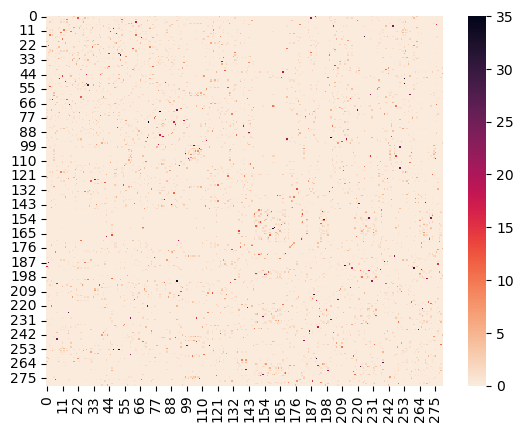

In [15]:
lattice = make_lattice_null(elegans_adj)
sns.heatmap(lattice, cmap='rocket_r')
#plt.savefig('lattice_example.png')

<Axes: >

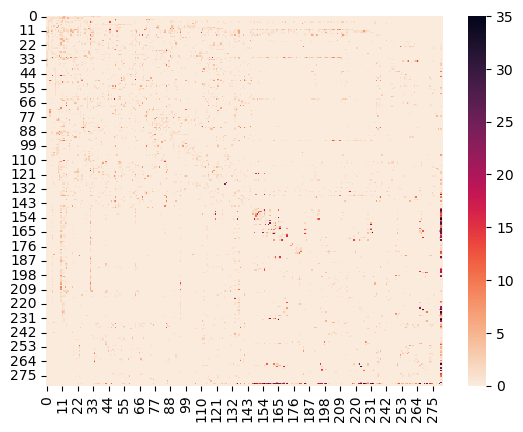

In [16]:
sns.heatmap(elegans_adj, cmap='rocket_r')

In [51]:
adj = sc.copy()
# Compute distance matrix using shortest paths on binary version of network
with np.errstate(divide='ignore'):
    edge_dist = np.where(adj > 0, 1.0 / adj, np.inf)
np.fill_diagonal(edge_dist, 0)
dist_matrix = shortest_path(edge_dist, method='auto', directed=False)
max_finite = dist_matrix[np.isfinite(dist_matrix)].max()
dist_matrix = np.where(np.isinf(dist_matrix), max_finite * 2, dist_matrix)
mds = MDS(n_components=1, random_state=59, dissimilarity='precomputed')
positions = mds.fit_transform(dist_matrix)
node_order = np.argsort(positions.flatten())

/apps/software/standard/core/jupyterlab/4.4.6-py3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
